In [1]:
# Project setup
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
pd.options.display.float_format = '{:,.0f}'.format # gets rid of scientific notation for some stats
df = pd.read_csv("Beatles.csv")

# Introduction - The Beatles Discography Analysis
The Beatles were a rock band who dominated the 1960s, commercially and culturally. Starting as teenagers playing skiffle music in Liverpool, they evolved into something far more ambitious, incorporating psychadelia, classical arrangements, Indian ragas, and pioneering studio techniques that set them apart from virtually every contemporary. 

This reputation wasn't always set in stone, however. Their earlier work, while charming, feels considerably simpler and more pop-oriented than what came later. The question this analysis attempts to answer: was there a real, measurable shift in quality and musicality after *Rubber Soul* (1965), the album widely considered to be the turning point in their catalog?

The dataset used here contains every canonical Beatles song, and was compiled by me from a base Kaggle dataset (sourced in README), with additional columns added from RateYourMusic, AlbumOfTheYear, and Spotify. Columns fall into two broad categories: identification (song and release details), and reception (critical rankings and listener ratings).

Column explanations:
| Column | Description |
|--------|-------------|
| id | Song id |
| Side | Album Side |
| Position | Album Position |
| Title | Song Title |
| Date | Date Released |
| Album | Album Title |
| Duration | Song Duration (s) |
| Songwriter | Chief Songwriter(s) |
| LeadVocal | Lead Vocalist(s) |
| Single | Single Side |
| UCM_T50 | UCM Top 50 Ranking |
| RS_T100 | Rolling Stones Top 100 Ranking |
| NME_Rank | NME Ranking |
| USA_Today_rank | USA Today Ranking |
| RYM | RateYourMusic Rating |
| AOTY | AlbumOfTheYear Rating |
| Spotify | Spotify Streams |

Extra notes:
- Date usually defers to the earliest release, i.e. Strawberry Fields forever was both a single and on Magical Mystery Tour, but was first released as a single on 2/13/1967
- Album is 'Single' for singles
- Songwriter is a bit of a murky datapoint. I took from an exhaustive research project into every song's chief songwriter (as all are credited under Lennon-McCartney, and sometimes Harrison/Starr), though some are bound to be a bit less accurate than others
- Single is 0 for non-singles, 1 for A-sides, 2 for B-sides
- RYM data is from 2024, though overall trends should not have changed very much
- For full dataset sources and modifications, see the README

# Setup

In [2]:
# Adjust scales
df['RYM_scaled'] = df['RYM'] * 20  # Scales RYM to 0-100

# Create avg_rating column
df['avg_rating'] = (df['RYM_scaled'] + df['AOTY']) / 2

# Ensure 'Date' column is in datetime format (stuff gets messed up otherwise)
df['Date'] = pd.to_datetime(df['Date'])

# Define custom album order since I can't do it by date
album_order = ['Single', 'Please Please Me', 'With the Beatles', "A Hard Day's Night", 
               'Beatles for Sale', 'Help!', 'Rubber Soul', 'Revolver', 
               "Sgt. Pepper's Lonely Hearts Club Band", 'Magical Mystery Tour', 
               'The Beatles', 'Yellow Submarine', 'Abbey Road', 'Let It Be']

# Define Rubber Soul split
rubber_soul_date = pd.to_datetime('1965-12-03')
pre_rs = df[df['Date'] < rubber_soul_date]
post_rs = df[df['Date'] >= rubber_soul_date]

# Loading
## 1. Dataset Overview

In [3]:
# Dimensions, variable types, and a look at the first 5 rows
print(df.shape)
print(df.dtypes)
df.head()

(206, 19)
id                         int64
Side                         str
Position                 float64
Title                        str
Date              datetime64[us]
Album                        str
Duration                   int64
Songwriter                   str
LeadVocal                    str
Single                     int64
UCM_T50                  float64
RS_T100                  float64
NME_Rank                 float64
USA_Today_rank           float64
RYM                      float64
AOTY                     float64
Spotify                    int64
RYM_scaled               float64
avg_rating               float64
dtype: object


,id,Side,Position,Title,Date,Album,Duration,Songwriter,LeadVocal,Single,UCM_T50,RS_T100,NME_Rank,USA_Today_rank,RYM,AOTY,Spotify,RYM_scaled,avg_rating
0,1,A,1,I Saw Her Standing There,1963-03-22,Please Please Me,175,McCartney,McCartney,0,17,16,28,17,4,84,190478793,83,83
1,2,A,2,Misery,1963-03-22,Please Please Me,107,Lennon-McCartney,Lennon-McCartney,0,NaN,NaN,156,177,4,74,18507350,71,72
2,3,A,3,Anna (Go to Him),1963-03-22,Please Please Me,168,Cover,Lennon,0,NaN,NaN,NaN,NaN,4,76,47967239,73,74
3,4,A,4,Chains,1963-03-22,Please Please Me,143,Cover,Harrison,0,NaN,NaN,NaN,NaN,3,66,11607495,63,64
4,5,A,5,Boys,1963-03-22,Please Please Me,144,Cover,Starr,0,NaN,NaN,NaN,NaN,3,66,14823209,64,65


## 2. Some Overall Stats

In [4]:
# Total number of songs
total_songs = len(df)

# Total singles and albums (NaN in Album column signifies a single)
total_singles = (df['Album'] == 'Single').sum()
total_album_songs = total_songs - total_singles

# Date range covered
earliest_date = df['Date'].min().date()
latest_date = df['Date'].max().date()

# Total and average duration
total_duration = df['Duration'].sum()
avg_duration = df['Duration'].mean()

# Songs by album
songs_by_album = df.groupby('Album').size().reindex(album_order)

# Averages and total
avg_rym = df['RYM_scaled'].mean()
avg_aoty = df['AOTY'].mean()
avg_rating = df['avg_rating'].mean()
total_streams = df['Spotify'].sum()
avg_streams = df['Spotify'].mean()

print(f"Total songs: {total_songs}, Singles: {total_singles}, Album songs: {total_album_songs}")
print(f"Covering {earliest_date} to {latest_date}")
print(f"Total duration: {total_duration/60} minutes, Avg duration: {avg_duration:.1f} seconds")
print("Songs by album: ")
print(songs_by_album)
print(f"Average RYM Rating (scaled): {avg_rym:.2f}")
print(f"Average AOTY Rating: {avg_aoty:.2f}")
print(f"Average Rating: {avg_rating:.2f}")
print(f"Total Spotify Streams: {total_streams:,}")
print(f"Average Spotify Streams: {avg_streams:,.0f}")

Total songs: 206, Singles: 22, Album songs: 184
Covering 1962-10-05 to 1970-05-08
Total duration: 563.1 minutes, Avg duration: 164.0 seconds
Songs by album: 
Album
Single                                   22
Please Please Me                         14
With the Beatles                         14
A Hard Day's Night                       13
Beatles for Sale                         14
Help!                                    14
Rubber Soul                              14
Revolver                                 14
Sgt. Pepper's Lonely Hearts Club Band    13
Magical Mystery Tour                     11
The Beatles                              30
Yellow Submarine                          4
Abbey Road                               17
Let It Be                                12
dtype: int64
Average RYM Rating (scaled): 77.31
Average AOTY Rating: 81.89
Average Rating: 79.68
Total Spotify Streams: 18,680,089,195
Average Spotify Streams: 90,680,045


# Question 1: Rating Landscape
## Explanation and Context
How are Beatles songs rated across their discography, and is there a visible shift around Rubber Soul?

This is good to explore to give an establishing shot of the data. The average rating is one of the most important metrics for our questions, as it allows us to measure what the public believes to be The Beatles' best work. Plotting rating over time allows us to see how they might have grown over time, how each album was received, and what trends we can extract from the data.

## Analysis and Chart Code

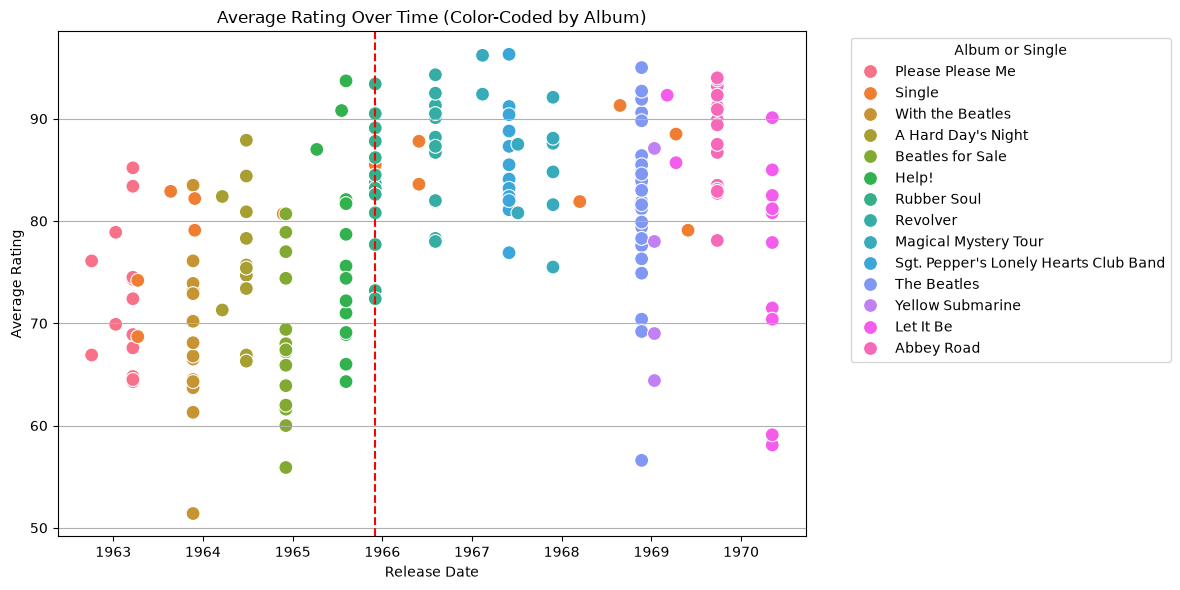

In [34]:
# Scatter plot with date on x-axis, avg_rating on y-axis, color coded by album. Add vertical line at Rubber Soul date so split is visually obvious

# Sort dataframe by date
df = df.sort_values(by='Date')

# Plot avg_rating over time, color coded by album
plt.figure(figsize=(12,6)) # Specifying so it's not too small
sns.scatterplot(data=df, x='Date', y='avg_rating', hue='Album', s=100)

# Add/modify labels and title
plt.xlabel("Release Date")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time (Color-Coded by Album)")
plt.legend(title='Album or Single', bbox_to_anchor=(1.05,1), loc='upper left')
plt.axvline(x=rubber_soul_date, color='red', linestyle='--', label='Rubber Soul (1965)')
plt.grid(axis='y')
plt.tight_layout() 
plt.show()

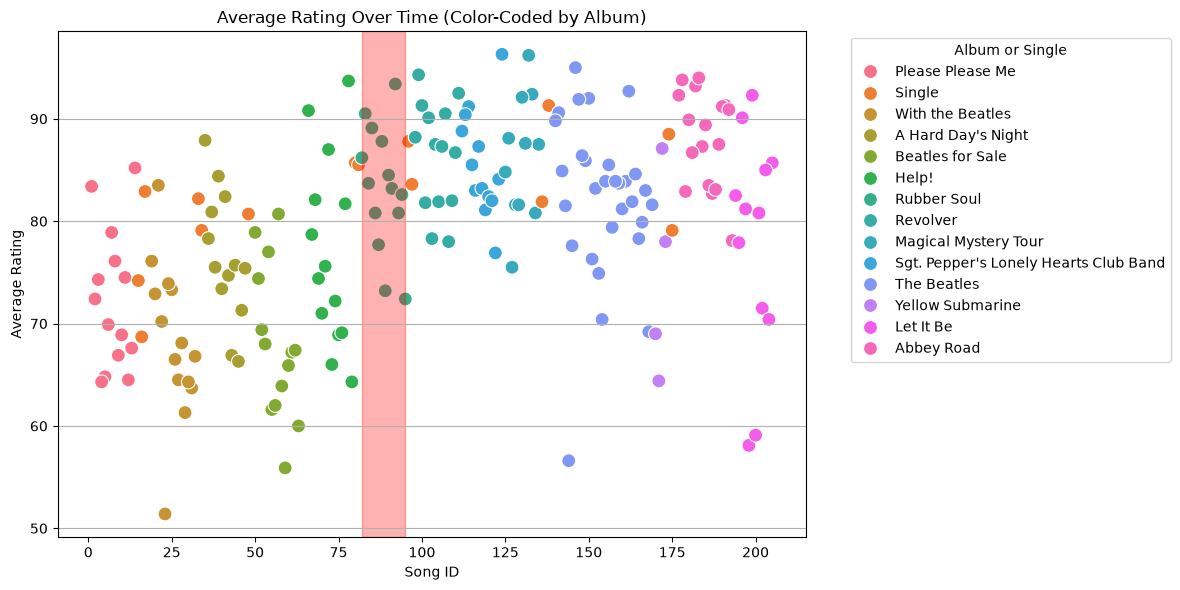

In [35]:
# Same plot but using id instead of date (so you can see the difference between positions as well)
# Plot avg_rating over time, color coded by album
plt.figure(figsize=(12,6)) # Specifying so it's not too small
sns.scatterplot(data=df, x='id', y='avg_rating', hue='Album', s=100)

# Add/modify labels and title
plt.xlabel("Song ID")
plt.ylabel("Average Rating")
plt.title("Average Rating Over Time (Color-Coded by Album)")
plt.legend(title='Album or Single', bbox_to_anchor=(1.05,1), loc='upper left')
plt.axvspan(82, 95, color="red", alpha=0.3, label='Rubber Soul IDs (1965)')
plt.grid(axis='y')
plt.tight_layout() 
plt.show()

## Observations and Conclusions
From these two charts, it's evident there exists a shift post-Rubber Soul. A few observations:
- Songs seem to not rate as lowly in the post-Rubber Soul dataset as the pre-Rubber Soul dataset, with fewer songs getting an average rating below 70.
- Songs also reach higher highs: while the pre-Rubber Soul dataset has only a handful of songs with an average rating over 90, the post-Rubber Soul era has many, many more (even accounting for the fact that there were more songs in general).
- Albums appear to be much more consistent as a whole. This is especially true for projects where the output was much more constrained/intentional (Revolver, Magical Mystery Tour, Abbey Road) compared to those where The Beatles were allowed to 'mess around' more (The White Album, Yellow Submarine, Let It Be)

Overall, I'm fairly surprised by how sudden the shift seems. While Rubber Soul does seem to be the inflection point, it only takes one album from them to go from fairly mediocre/good to consistently great.

The data seems to show that there was a significant shift in quality around Rubber Soul, though the actual cause cannot be gleamed from this graph alone. 

# Question 2: Song Duration
## Explanation and Context
Did song lengths change after Rubber Soul, and what does that suggest about the band's creative direction?

While musical experimentation is not something that is easy to quantify, looking at the spread of runtimes of Beatles songs would help in seeing an aspect of their music that changed over time. How did their average song length change over time? Did ceasing to tour give them greater freedom to make songs that they couldn't reasonably play live? Can you see any divergence or trend in song length over time?

## Analysis and Chart Code

In [ ]:
# Code here
# Same idea as above, except duration should go on y. From testing I know the split is more around Sgt. Pepper's, but that can still be an interesting
# observation to make in the conclusions section (perhaps runtime specifically was more impacted by the technology at the time, or it was a lagging
# indicator). Also a rolling average line would make trend clearer against the scatter

## Observations and Conclusions

# Question 3: Songwriter Contributions
## Explanation and Context
How did songwriting credits shift across the Beatles' career, and does the post-Rubber Soul era look compositionally different?

One of the most interesting facts about The Beatles is that every member has composed at least one song in their catalog, with all four going on to have significant solo careers after the band's breakup. While some (i.e. Lennon and McCartney) obviously dominated when it came to creating songs for the band, how did the actual composition of songwriters change over time? Is there a real difference pre and post-Rubber Soul? What might this suggest, if so?

## Analysis and Chart Code

In [ ]:
# Code here
# Stacked area chart or grouped bar chart by album showing proportion of songs credited to either Lennon, McCartney, Harrison, or Starr. Because
# there are plenty of co-worked songs, I think it's fair to just count some songs for whatever lead songwriters are present. 

## Observations and Conclusions

# Main Question: The Rubber Soul Question
## Explanation and Context
Is the perceived quality shift after Rubber Soul statistically significant, or just a matter of perception?

I would certainly agree that The Beatles' output post-1965 was much changed, but that's only speaking from my personal tastes and experiences. Does this hold up statistically? With all the data we now have, can the data support the claim that there was a real shift post-Rubber Soul?

## Analysis and Chart Code

In [ ]:
# Code here
# Side by side box plot or violin plot showing rating distribution for pre vs post Rubber Soul songs, followed by a ttest

## Observations and Conclusions

# Conclusion